# Notebook 1: Einführung

## Erste Schritte mit Linearer Regression

In [2]:
# Laden der notwendigen Bibliotheken
import pandas as pd
import numpy as np
import sklearn
from sklearn import linear_model
import statsmodels.api as sm
import matplotlib.pyplot as plt

## Vorbereitung

Zuerst laden wir Daten zur Gehaltsverteilung:

In [4]:
wage_data = pd.read_csv('../data/raw/wage_data.csv')
wage_data

,wage,educ,exper,tenure,nonwhite,female,married
0,3.10,11,2,0,0,1,0
1,3.24,12,22,2,0,1,1
2,3.00,11,2,0,0,0,0
3,6.00,8,44,28,0,0,1
4,5.30,12,7,2,0,0,1
...,...,...,...,...,...,...,...
521,15.00,16,14,2,0,1,1
522,2.27,10,2,0,0,1,0
523,4.67,15,13,18,0,0,1
524,11.56,16,5,1,0,0,1


`Wage` ist die Outputvariable, während die anderen Faktoren als Input Variablen dienen:

In [7]:
input_variables = wage_data.drop("wage", axis=1)
output_variable = wage_data["wage"]

Wir können darauf nun ein einfaches Modell (Lineare Regression) trainieren:

In [8]:
linear_regression = linear_model.LinearRegression().fit(input_variables, output_variable)

Ergebnis dieser Regression:

In [9]:
print(round(linear_regression.intercept_, 2), *[str(round(val, 2)) + " * " + name for name, val in zip(input_variables.columns, linear_regression.coef_)], sep=" + ")

-1.6 + 0.56 * educ + 0.02 * exper + 0.14 * tenure + -0.07 * nonwhite + -1.74 * female + 0.56 * married


## Inferenz
Wir können uns die Koeffizienten des Modells anschauen, um die Beziehung zwischen den Input Variablen und der Output Variable zu verstehen

In [10]:
print("Intercept", round(linear_regression.intercept_,2))
pd.DataFrame(linear_regression.coef_.round(2), index=input_variables.columns, columns=["Coefficient"])

Intercept -1.6


,Coefficient
educ,0.56
exper,0.02
tenure,0.14
nonwhite,-0.07
female,-1.74
married,0.56


Auf Basis der Koeffizienten, können wir Schlüsse über die Beziehung ziehen:
- Männer verdienen 1.74€ pro Stunde mehr als Frauen
- Ein zusätzliches Jahr an Erfahrung bringt nur 2 Cent mehr pro Stunde
- Ein zusätzliches Jahr in der Schule/Uni bringt 56 Cent mehr pro Stunde
- Die Basisgruppe (0 Jahre Schule, keine Erfahrung, ...) verdient -1.6€ pro Stunde...

## Vorhersage

Wir können das Modell nutzen um den Lohn einer neuen Person vorherzusagen:

In [11]:
new_person = pd.DataFrame([[15,  8,  2,  1,  0,  0]], columns=input_variables.columns, index=["New Person"])
new_person

,educ,exper,tenure,nonwhite,female,married
New Person,15,8,2,1,0,0


In [12]:
print("Predicted Wage:", round(linear_regression.predict(new_person)[0],2))

Predicted Wage: 7.09


## Kategorische Daten und Dummy Variablen

In [13]:
# Datendefinition
categorical_data = pd.DataFrame(["Video", "Bild", "Video", "Bild", "Bild", "Text"], columns=["Dateityp"])
categorical_data

,Dateityp
0,Video
1,Bild
2,Video
3,Bild
4,Bild
5,Text


In [14]:
# manuelles Encoding
categorical_data["Video"] = [1 if x=="Video" else 0 for x in categorical_data["Dateityp"]]
categorical_data["Text"] = [1 if x=="Text" else 0 for x in categorical_data["Dateityp"]]

# Redundante Informationen, daher werden nur n-1 Variablen gebraucht
# categorical_data["Bild"] = [1 if x=="Bild" else 0 for x in categorical_data["Dateityp"]]

categorical_data

,Dateityp,Video,Text
0,Video,1,0
1,Bild,0,0
2,Video,1,0
3,Bild,0,0
4,Bild,0,0
5,Text,0,1


In [15]:
# Encoding mit sklearn:
encoder = sklearn.preprocessing.OneHotEncoder(sparse_output=False).fit(categorical_data[["Dateityp"]])
encoded_data = encoder.transform(categorical_data[["Dateityp"]])
encoded_data = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out())
categorical_data[["Dateityp"]].join(encoded_data)

,Dateityp,Dateityp_Bild,Dateityp_Text,Dateityp_Video
0,Video,0.0,0.0,1.0
1,Bild,1.0,0.0,0.0
2,Video,0.0,0.0,1.0
3,Bild,1.0,0.0,0.0
4,Bild,1.0,0.0,0.0
5,Text,0.0,1.0,0.0


In [16]:
sklearn.preprocessing.OneHotEncoder(sparse_output=False, drop="first").fit_transform(categorical_data[["Dateityp"]])

array([[0., 1.],
       [0., 0.],
       [0., 1.],
       [0., 0.],
       [0., 0.],
       [1., 0.]])

## Interaktionen von Dummy Variablen

Zuerst können wir eine lineare Regression bilden ohne Interaktionen zwischen den Variablen

In [14]:
example_input = input_variables[["female", "tenure"]]

linear_regression = linear_model.LinearRegression().fit(example_input, output_variable)

In [15]:
result = pd.DataFrame(np.append(linear_regression.intercept_, linear_regression.coef_).round(2),
                      index=np.append("Intercept", example_input.columns), columns=["Coefficient"])
result

,Coefficient
Intercept,6.14
female,-2.09
tenure,0.15


In [16]:
# Printing the linear regression term
print(round(linear_regression.intercept_, 2), *[str(round(val, 2)) + " * " + name for name, val in zip(example_input.columns, linear_regression.coef_)], sep=" + ")

6.14 + -2.09 * female + 0.15 * tenure


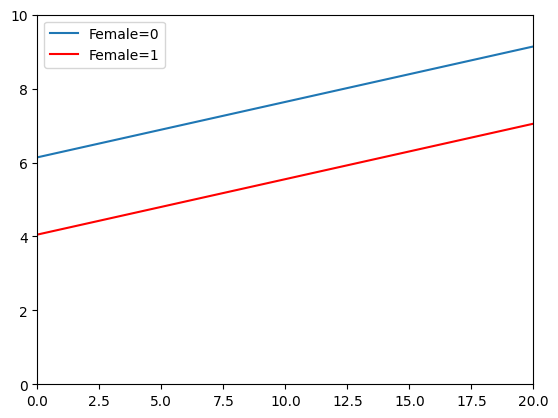

In [17]:
fig, ax = plt.subplots()

plotting_data = result["Coefficient"]
ax.axline((0, plotting_data["Intercept"]), slope=plotting_data["tenure"], label="Female=0")
ax.axline((0, plotting_data["Intercept"] + plotting_data["female"]), slope=plotting_data["tenure"], label="Female=1", color="Red")
ax.set_xlim(0, 20)
ax.set_ylim(0, 10) 
ax.legend()

plt.show()

**Hinzufügen der Interaktion**

In [18]:
new_input_variables = example_input.copy()
new_input_variables["female_tenure"] = new_input_variables["female"] * new_input_variables["tenure"]
linear_regression = linear_model.LinearRegression().fit(new_input_variables, output_variable)
result = pd.DataFrame(np.append(linear_regression.intercept_, linear_regression.coef_).round(2),
                      index=np.append("Intercept", new_input_variables.columns), columns=["Coefficient"])
result

,Coefficient
Intercept,5.93
female,-1.58
tenure,0.18
female_tenure,-0.12


In [19]:
print(round(linear_regression.intercept_, 2), *[str(round(val, 2)) + " * " + name for name, val in zip(new_input_variables.columns, linear_regression.coef_)], sep=" + ")

5.93 + -1.58 * female + 0.18 * tenure + -0.12 * female_tenure


In [20]:
plotting_data

Intercept    6.14
female      -2.09
tenure       0.15
Name: Coefficient, dtype: float64

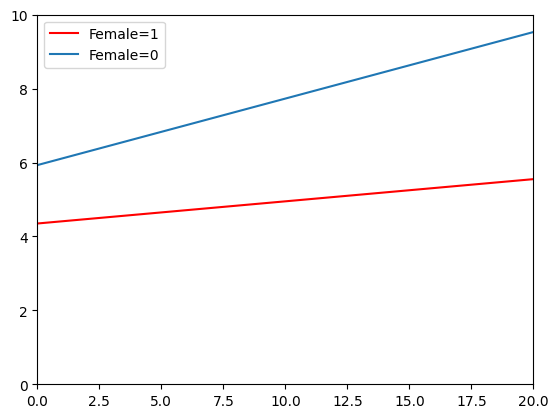

In [21]:
fig, ax = plt.subplots()

plotting_data = result["Coefficient"]
ax.axline((0, plotting_data["Intercept"] + plotting_data["female"]), slope=plotting_data["tenure"] + plotting_data["female_tenure"], label="Female=1", color="Red")
ax.axline((0, plotting_data["Intercept"]), slope=plotting_data["tenure"], label="Female=0")
ax.set_xlim(0, 20)
ax.set_ylim(0, 10) 
ax.legend()

plt.show()

## Statistische Eigenschaften der Regression
sci-kit Learn als Bibliothek ist nicht für einige der mehr statistischen Methoden geignet, stattdessen nutzen wir hier eine andere Bibliothek und Funktion:

In [22]:
model = sm.OLS(output_variable, sm.add_constant(input_variables)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.368
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     50.41
Date:                Sun, 07 Sep 2025   Prob (F-statistic):           8.27e-49
Time:                        12:50:02   Log-Likelihood:                -1312.3
No. Observations:                 526   AIC:                             2639.
Df Residuals:                     519   BIC:                             2668.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6022      0.731     -2.192      0.029      -3.038      -0.166
educ           0.5551      0.050     11.090      0.000       0.457       0.653
exper          0.0187      0.012      1.557      0.120      -0.005       0.042
tenure         0.1388      0.021      6.562      0.000       0.097       0.180
nonwhite      -0.0658      0.427     -0.154      0.877      -0.904       0.772
female        -1.7424      0.267     -6.530      0.000      -2.267      -1.218
married        0.5566      0.287      1.941      0.053      -0.007       1.120
==============================================================================
Omnibus:                      188.311   Durbin-Watson:                   1.795
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              728.036
Skew:                           1.611   Prob(JB):                    8.11e-159
Kurtosis:                       7.779   Cond. No.                         143.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Wichtige Eigenschaften für die Interpretation:
- Koeffizienten und Standard Error der Koeffizienten (bzw. p-values)
- R^2 Wert
- Stichprobengöße

Allgemein hat das Modell einen R^2 Wert von ca 0.37 (also etwa 37% der Varianz im Gehalt wird durch die Input-Variablen erklärt). Das Modell ist allgemein statistisch relevant (siehe P-Wert der F-Statistik), wobei es mit Sicherheit noch Verbesserungspotential für das Modell gibt. 
Basierend auf den p-Werten können wir die Variablen `nonwhite` und `exper` aus dem Model ausschließen, ohne dass sich der adjustierte R^2 Wert groß verändern sollte:

In [23]:
model = sm.OLS(output_variable, sm.add_constant(input_variables.drop(["nonwhite", "exper"], axis=1))).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.360
Method:                 Least Squares   F-statistic:                     74.95
Date:                Sun, 07 Sep 2025   Prob (F-statistic):           3.66e-50
Time:                        12:50:02   Log-Likelihood:                -1313.5
No. Observations:                 526   AIC:                             2637.
Df Residuals:                     521   BIC:                             2658.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1385      0.655     -1.738      0.083      -2.426       0.149
educ           0.5294      0.047     11.268      0.000       0.437       0.622
tenure         0.1542      0.019      8.241      0.000       0.117       0.191
female        -1.7105      0.266     -6.428      0.000      -2.233      -1.188
married        0.6852      0.275      2.495      0.013       0.146       1.225
==============================================================================
Omnibus:                      189.042   Durbin-Watson:                   1.797
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              728.197
Skew:                           1.619   Prob(JB):                    7.48e-159
Kurtosis:                       7.768   Cond. No.                         73.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Wir können auch weitere Interaktionsterme und funktionale Formen hinzufügen um zu schauen ob diese relevant sind:

In [24]:
new_input_variables = sm.add_constant(input_variables.drop(["nonwhite", "exper"], axis=1))

# Funktionale Form
new_input_variables["sqrt_tenure"] = np.sqrt(new_input_variables["tenure"])
new_input_variables["log_educ"] = np.log(new_input_variables["educ"]+0.001)

# Interaktionsvariablen
new_input_variables["female_married"] = new_input_variables["female"] * new_input_variables["married"]
new_input_variables["female_tenure"] = new_input_variables["female"] * new_input_variables["tenure"]

# Neue Kalkulation des Modells
model = sm.OLS(output_variable, new_input_variables).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   wage   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     45.52
Date:                Sun, 07 Sep 2025   Prob (F-statistic):           2.92e-55
Time:                        12:50:02   Log-Likelihood:                -1292.8
No. Observations:                 526   AIC:                             2604.
Df Residuals:                     517   BIC:                             2642.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.6847      0.684     -2.462      0.014      -3.029      -0.340
educ               0.6254      0.058     10.756      0.000       0.511       0.740
tenure             0.0794      0.047      1.676      0.094      -0.014       0.172
female             0.0164      0.420      0.039      0.969      -0.808       0.841
married            1.6081      0.392      4.097      0.000       0.837       2.379
sqrt_tenure        0.5374      0.234      2.297      0.022       0.078       0.997
log_educ          -0.7459      0.252     -2.958      0.003      -1.241      -0.251
female_married    -1.9629      0.533     -3.682      0.000      -3.010      -0.916
female_tenure     -0.1321      0.042     -3.180      0.002      -0.214      -0.050
==============================================================================
Omnibus:                      186.044   Durbin-Watson:                   1.781
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              719.477
Skew:                           1.589   Prob(JB):                    5.86e-157
Kurtosis:                       7.768   Cond. No.                         93.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Anhand des p-Wertes können wir dort sehen, welche der Variablen statistisch relevant sind (p<0.05).

## Weiterführender Hypothesentest

**Interessant aber nicht Klausurrelevant**

Wir haben bereits gesehen, wie wir basierend auf den p-Werten einzelne Variablen aus dem Modell hinzufügen oder entfernen können, aber es gibt auch noch andere interessante Fragen die wir mit Hypothesentests beantworten können:

- Ist das Modell insgesamt überhaupt relevant?
- Hat ein Jahr Tenure den gleichen Effekt wie ein Jahr Education?

Die erste Frage lässt sich durch die bereits betrachtete Gesamt F-Statistik des Modell einfach beantworten. Die nächste Frage erfordert einen etwas anderen Ansatz:

Wir wollen wissen ob $\beta_1 = \beta_2$, oder anders ausgedrückt haben wir die Hypothese: $H_0:\beta_1 − \beta_2 = 0$

Dies können wir durch Reparametisierung des Modells testen: $𝑦=\theta x_1 + \beta_2 (x_1+x_2 )$ wobei $\theta = \beta_1 − \beta_2$ und damit $H_0:\theta = 0$

In [25]:
combination_input_variables = sm.add_constant(input_variables.drop(["nonwhite", "exper"], axis=1))
combination_input_variables["tenure_educ"] = combination_input_variables["tenure"] + combination_input_variables["educ"]
combination_input_variables = combination_input_variables.drop("tenure", axis=1)
model = sm.OLS(output_variable, combination_input_variables).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,-1.1385,0.655,-1.738,0.083,-2.426,0.149
educ,0.3752,0.049,7.657,0.000,0.279,0.471
female,-1.7105,0.266,-6.428,0.000,-2.233,-1.188
married,0.6852,0.275,2.495,0.013,0.146,1.225
tenure_educ,0.1542,0.019,8.241,0.000,0.117,0.191
